In [ ]:
import gzip
import json
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import re
import zipfile
from scipy.sparse import coo_matrix
from sklearn.neighbors import NearestNeighbors

from google.colab import drive
import os

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_path = '/content/drive/My Drive/Colab Notebooks/recommender'
os.listdir(folder_path)

['goodreads_books.json.gz',
 'book_id_map.csv',
 'goodreads_interactions.zip',
 'search.ipynb',
 'duckdb_version.ipynb',
 'recommender-3.ipynb']

In [ ]:
def parse_fields(line):
    data = json.loads(line)
    return {
        "book_id": data["book_id"],
        "title": data["title"],
        "average_rating": data["average_rating"],
        "ratings_count": data["ratings_count"],
        "url": data["url"],
        "cover_image": data["image_url"]
    }

In [ ]:
goodreads_books_path = folder_path + '/goodreads_books.json.gz'

books = []
with gzip.open(goodreads_books_path) as f:
    while True:
        line = f.readline()
        if not line:
            break
        fields = parse_fields(line)

        try:
            ratings_count = int(fields["ratings_count"])
            average_rating = float(fields["average_rating"])
        except ValueError:
            continue
        if ratings_count >= 100 and average_rating >= 3:
          books.append(fields)

In [ ]:
titles = pd.DataFrame.from_dict(books)
titles

,book_id,title,average_rating,ratings_count,url,cover_image
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",4.03,140,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...
1,6066819,Best Friends Forever,3.49,51184,https://www.goodreads.com/book/show/6066819-be...,https://s.gr-assets.com/assets/nophoto/book/11...
2,287149,The Devil's Notebook,3.81,986,https://www.goodreads.com/book/show/287149.The...,https://images.gr-assets.com/books/1328768789m...
3,6066814,"Crowner Royal (Crowner John Mystery, #13)",3.93,186,https://www.goodreads.com/book/show/6066814-cr...,https://images.gr-assets.com/books/1328724803m...
4,33394837,The House of Memory (Pluto's Snitch #2),4.33,269,https://www.goodreads.com/book/show/33394837-t...,https://images.gr-assets.com/books/1493114742m...
...,...,...,...,...,...,...
496956,15500943,"Not Quickly Broken (Chop, Chop, #7)",4.52,456,https://www.goodreads.com/book/show/15500943-n...,https://images.gr-assets.com/books/1381765124m...
496957,15734522,Why You're Not Married . . . Yet: The Straight...,3.79,101,https://www.goodreads.com/book/show/15734522-w...,https://images.gr-assets.com/books/1341351347m...
496958,1370179,The Brazilian Boss's Innocent Mistress,3.51,240,https://www.goodreads.com/book/show/1370179.Th...,https://s.gr-assets.com/assets/nophoto/book/11...
496959,17805813,"Ondine (Ondine Quartet, #0.5)",4.02,327,https://www.goodreads.com/book/show/17805813-o...,https://images.gr-assets.com/books/1379766592m...


In [ ]:
titles["ratings_count"] = pd.to_numeric(titles["ratings_count"])
titles["average_rating"] = pd.to_numeric(titles["average_rating"])
titles['book_id'] = titles['book_id'].astype(str)
titles["mod_title"] = titles["title"].str.replace("[^a-zA-Z0-9 ]", "", regex=True).str.lower()
titles["mod_title"] = titles["mod_title"].str.replace("\s+", " ", regex=True)
titles = titles[titles["mod_title"].str.len() > 0]
titles

,book_id,title,average_rating,ratings_count,url,cover_image,mod_title
0,7327624,"The Unschooled Wizard (Sun Wolf and Starhawk, ...",4.03,140,https://www.goodreads.com/book/show/7327624-th...,https://images.gr-assets.com/books/1304100136m...,the unschooled wizard sun wolf and starhawk 12
1,6066819,Best Friends Forever,3.49,51184,https://www.goodreads.com/book/show/6066819-be...,https://s.gr-assets.com/assets/nophoto/book/11...,best friends forever
2,287149,The Devil's Notebook,3.81,986,https://www.goodreads.com/book/show/287149.The...,https://images.gr-assets.com/books/1328768789m...,the devils notebook
3,6066814,"Crowner Royal (Crowner John Mystery, #13)",3.93,186,https://www.goodreads.com/book/show/6066814-cr...,https://images.gr-assets.com/books/1328724803m...,crowner royal crowner john mystery 13
4,33394837,The House of Memory (Pluto's Snitch #2),4.33,269,https://www.goodreads.com/book/show/33394837-t...,https://images.gr-assets.com/books/1493114742m...,the house of memory plutos snitch 2
...,...,...,...,...,...,...,...
496956,15500943,"Not Quickly Broken (Chop, Chop, #7)",4.52,456,https://www.goodreads.com/book/show/15500943-n...,https://images.gr-assets.com/books/1381765124m...,not quickly broken chop chop 7
496957,15734522,Why You're Not Married . . . Yet: The Straight...,3.79,101,https://www.goodreads.com/book/show/15734522-w...,https://images.gr-assets.com/books/1341351347m...,why youre not married yet the straight talk yo...
496958,1370179,The Brazilian Boss's Innocent Mistress,3.51,240,https://www.goodreads.com/book/show/1370179.Th...,https://s.gr-assets.com/assets/nophoto/book/11...,the brazilian bosss innocent mistress
496959,17805813,"Ondine (Ondine Quartet, #0.5)",4.02,327,https://www.goodreads.com/book/show/17805813-o...,https://images.gr-assets.com/books/1379766592m...,ondine ondine quartet 05


In [ ]:
len(titles["book_id"].unique())

495230

In [ ]:
valid_book_ids = set(titles["book_id"].unique())

In [ ]:
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform(titles["mod_title"])

In [ ]:
def search(query, vectorizer):
    processed = re.sub("[^a-zA-Z0-9 ]", "", query.lower())
    query_vec = vectorizer.transform([processed])
    similarity = cosine_similarity(query_vec, tfidf).flatten()
    indices = np.argpartition(similarity, -20)[-20:]
    sorted_indices = indices[np.argsort(similarity[indices])[::-1]]
    results = titles.iloc[sorted_indices].copy()
    results['similarity_score'] = similarity[sorted_indices]
    results['ratings_count'] = results['ratings_count'].astype(int)
    results = results.sort_values(by='ratings_count', ascending=False)
    return results.head(5)

In [ ]:
def create_my_books_df(my_titles_list, tfidf_vectorizer):
  my_books = pd.DataFrame()
  for title, rating in my_titles_list:
    results = search(title, tfidf_vectorizer)
    if not results.empty:
      results = results[["book_id", "title"]].copy()
      results["rating"] = rating
      results["user_id"] = "-1"
      my_books = pd.concat([my_books, results[["user_id","book_id","title","rating"]]])

    my_books = my_books.reset_index(drop=True)
    my_books['user_id'] = my_books['user_id'].astype(str)
    my_books['book_id'] = my_books['book_id'].astype(str)
    my_books["rating"] = pd.to_numeric(my_books["rating"])

  return my_books

In [ ]:
my_title_list = [("kingkiller", 5), ("The Lord of the Rings", 5), ("twilight", 3), ("eragon", 4), ("Harry Potter and the Sorcerer's Stone", 5), ("the mistborn",3),
                 ("brisingr", 4), ("a song of ice and fire", 5), ("how to train your dragon",3), ("percy jackson and the lightning thief",5), ("heroes of olympus", 3),
                 ("the 5th wave", 2), ("i am number four",4), ("pride and prejudice",1), ("The Forever War (The Forever War, #1)",1), ("The Smartest Guys in the Room",1),
                 ("The Mask of Command", 1), ("Endurance",1), ("Battle Cry of Freedom",1), ("Arkwright",1), ("fifty shades of grey",1)]

my_books = create_my_books_df(my_title_list, vectorizer)
my_books

,user_id,book_id,title,rating
0,-1,186074,The Name of the Wind (The Kingkiller Chronicle...,5
1,-1,20562717,The Name of the Wind (The Kingkiller Chronicle...,5
2,-1,2495567,The Name of the Wind (The Kingkiller Chronicle...,5
3,-1,2913377,The Name of the Wind (The Kingkiller Chronicle...,5
4,-1,11127294,The Name of the Wind (The Kingkiller Chronicle...,5
...,...,...,...,...
100,-1,10818853,"Fifty Shades of Grey (Fifty Shades, #1)",1
101,-1,25644601,"Grey (Fifty Shades, #4)",1
102,-1,18626824,"Fifty Shades of Grey (Fifty Shades, #1)",1
103,-1,25643846,"Grey (Fifty Shades, #4)",1


In [ ]:
mystery_books = [
    "The Girl with the Dragon Tattoo",
    "Gone Girl",
    "The Da Vinci Code",
    "Big Little Lies",
    "The Woman in White",
    "In the Woods",
    "The Secret History",
    "The Silent Patient",
    "The Reversal",
    "The Hound of the Baskervilles",
    "The No. 1 Ladies' Detective Agency",
    "Still Life",
    "The Cuckoo's Calling",
    "I Am Watching You",
    "Before I Go to Sleep",
    "In a Dark, Dark Wood",
    "The Family Upstairs",
    "The Dry",
    "Magpie Murders",
    "The Thursday Murder Club"
]

In [ ]:
import polars as pl

interactions_path = folder_path + '/goodreads_interactions.zip'
# Read zipped interactions
with zipfile.ZipFile(interactions_path) as z:
    file_name = z.namelist()[0]
    with z.open(file_name) as f:
        df = pl.read_csv(
            f,
            columns=["user_id", "book_id", "rating"],  # only these columns will be read
            schema_overrides={
                "user_id": pl.String,
                "book_id": pl.String,
                "rating": pl.Int8
            }
        )

In [ ]:
df

user_id,book_id,rating
str,str,i8
"""0""","""948""",5
"""0""","""947""",5
"""0""","""946""",5
"""0""","""945""",5
"""0""","""944""",5
…,…,…
"""876144""","""24772""",0
"""876144""","""23847""",4
"""876144""","""23950""",3


In [ ]:
df.shape

(228648342, 3)

<ipython-input-14-3172196903>:6: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  .count()


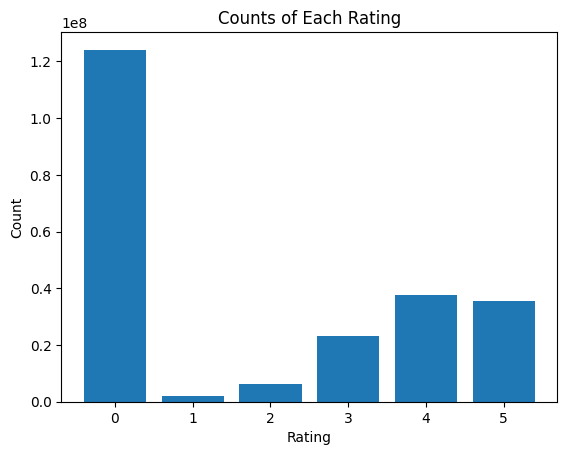

In [ ]:
import matplotlib.pyplot as plt

# Convert to Pandas for plotting
rating_counts = (
    df.group_by("rating")
      .count()
      .sort("rating")
      .to_pandas()
)

plt.bar(rating_counts["rating"], rating_counts["count"])
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Counts of Each Rating")
plt.show()

In [ ]:
book_mapping_csv_path = folder_path + '/book_id_map.csv'
book_mapping = pl.read_csv(
                            book_mapping_csv_path,
                            columns = ["book_id_csv", "book_id"],  # only these columns will be read
                            schema_overrides = {
                                              "book_id_csv": pl.String,
                                              "book_id": pl.String,
                                             }
                          )
book_mapping

book_id_csv,book_id
str,str
"""0""","""34684622"""
"""1""","""34536488"""
"""2""","""34017076"""
"""3""","""71730"""
"""4""","""30422361"""
…,…
"""2360645""","""19517100"""
"""2360646""","""18597299"""
"""2360647""","""18584882"""


In [ ]:
interactions = df.join(book_mapping, how='left', left_on='book_id', right_on='book_id_csv')
interactions

user_id,book_id,rating,book_id_right
str,str,i8,str
"""0""","""948""",5,"""12"""
"""0""","""947""",5,"""21"""
"""0""","""946""",5,"""30"""
"""0""","""945""",5,"""45"""
"""0""","""944""",5,"""1"""
…,…,…,…
"""876144""","""24772""",0,"""17191046"""
"""876144""","""23847""",4,"""19042398"""
"""876144""","""23950""",3,"""20317106"""


In [ ]:
interactions.shape

(228648342, 4)

In [ ]:
interactions =interactions.filter( pl.col('book_id_right').is_in(valid_book_ids))
interactions

user_id,book_id,rating,book_id_right
str,str,i8,str
"""0""","""948""",5,"""12"""
"""0""","""947""",5,"""21"""
"""0""","""946""",5,"""30"""
"""0""","""945""",5,"""45"""
"""0""","""944""",5,"""1"""
…,…,…,…
"""876144""","""38802""",0,"""3347854"""
"""876144""","""38968""",0,"""5582346"""
"""876144""","""412772""",0,"""7040230"""


In [ ]:
interactions.shape

(201440349, 4)

In [ ]:
interactions.null_count()

user_id,book_id,rating,book_id_right
u32,u32,u32,u32
0,0,0,0


In [ ]:
interactions = interactions.drop(['book_id']).rename({'book_id_right': 'book_id'})
interactions = interactions.select(['user_id','book_id','rating'])
interactions

user_id,book_id,rating
str,str,i8
"""0""","""12""",5
"""0""","""21""",5
"""0""","""30""",5
"""0""","""45""",5
"""0""","""1""",5
…,…,…
"""876144""","""3347854""",0
"""876144""","""5582346""",0
"""876144""","""7040230""",0


In [ ]:
interactions

user_id,book_id,rating
str,str,i8
"""0""","""12""",5
"""0""","""21""",5
"""0""","""30""",5
"""0""","""45""",5
"""0""","""1""",5
…,…,…
"""876144""","""3347854""",0
"""876144""","""5582346""",0
"""876144""","""7040230""",0


In [ ]:
my_books_pl = pl.from_pandas(
                              my_books,
                              schema_overrides = {
                                                "user_id": pl.String,
                                                "book_id": pl.String,
                                                "rating": pl.Int8
                                               }
                             ).select(["user_id", "book_id", "rating"])
my_books_pl

user_id,book_id,rating
str,str,i8
"""-1""","""10818853""",5
"""-1""","""25644601""",5
"""-1""","""18626824""",5
"""-1""","""25643846""",5
"""-1""","""13536858""",5
…,…,…
"""-1""","""213395""",5
"""-1""","""908958""",5
"""-1""","""696340""",5


In [ ]:
combined_interactions = pl.concat([my_books_pl,interactions])

In [ ]:
len(combined_interactions["user_id"].unique())

868199

In [ ]:
len(combined_interactions["book_id"].unique())

495230

In [ ]:
def create_user_item_matrix(df):
    # Convert to Pandas
    df_pd = df.to_pandas()

    user_mapper = {user_id: i for i, user_id in enumerate(df_pd['user_id'].unique())}
    book_mapper = {book_id: i for i, book_id in enumerate(df_pd['book_id'].unique())}

    user_index = df_pd['user_id'].map(user_mapper).values
    book_index = df_pd['book_id'].map(book_mapper).values

    X = coo_matrix((df_pd['rating'], (user_index, book_index)))

    return X.tocsr(), user_mapper, book_mapper

In [ ]:
X, user_mapper, book_mapper = create_user_item_matrix(combined_interactions)

In [ ]:
X.shape

(868199, 495230)

In [ ]:
n_total = X.shape[0]*X.shape[1]
n_ratings = X.nnz
sparsity = n_ratings/n_total
print(f"Matrix percentage filled: {round(sparsity*100,2)}% \nMatrix percentage empty: {100-round(sparsity*100,2)}%")

Matrix percentage filled: 0.05% 
Matrix percentage empty: 99.95%


In [ ]:
user_mapper["-1"]

0

In [ ]:
def find_similar_users(user_id, X, user_mapper, k=10, metric='cosine'):
    if user_id not in user_mapper:
        print(f"User ID {user_id} not found.")
        return []

    user_indice = user_mapper[user_id]
    user_vec = X[user_indice]

    kNN = NearestNeighbors(n_neighbors=k+1, metric=metric)
    kNN.fit(X)

    dist, neighbours_indices = kNN.kneighbors(user_vec, return_distance=True)
    neighbours_indices = neighbours_indices.flatten()
    dist = dist.flatten().tolist()
    indice_to_user_mapper = {v: k for k, v in user_mapper.items()}
    neighbours_user_ids = [indice_to_user_mapper[n] for n in neighbours_indices]

    neighbours = [id for id in neighbours_user_ids if id != user_id]
    similar_users_df = pl.DataFrame({
                                      "user_id": neighbours_user_ids,
                                      "similarity_score": dist
                                    },
                                      schema_overrides = {
                                                          "user_id": pl.String,
                                                        },
                                      strict=False
                                    ).filter(pl.col("user_id") != user_id)
    return similar_users_df

In [ ]:
similar_users = find_similar_users('-1', X, user_mapper, k=20)
# print(len(similar_users))
similar_users

user_id,similarity_score
str,f64
"""242822""",0.7332
"""833057""",0.76019
"""630222""",0.774641
"""517083""",0.776452
"""628568""",0.795077
…,…
"""466236""",0.821637
"""459237""",0.821749
"""780846""",0.821855


In [ ]:
titles_pl = pl.from_pandas(
                              titles,
                              schema_overrides = {
                                                "book_id": pl.String,
                                                "title": pl.String,
                                                "average_rating": pl.Float32,
                                                "ratings_count": pl.Int32,
                                                "url": pl.String,
                                                "cover_image": pl.String,
                                                "mod_title": pl.String
                                               }
                             )
titles_pl

book_id,title,average_rating,ratings_count,url,cover_image,mod_title
str,str,f32,i32,str,str,str
"""7327624""","""The Unschooled Wizard (Sun Wol…",4.03,140,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""the unschooled wizard sun wolf…"
"""6066819""","""Best Friends Forever""",3.49,51184,"""https://www.goodreads.com/book…","""https://s.gr-assets.com/assets…","""best friends forever"""
"""287149""","""The Devil's Notebook""",3.81,986,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""the devils notebook"""
"""6066814""","""Crowner Royal (Crowner John My…",3.93,186,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""crowner royal crowner john mys…"
"""33394837""","""The House of Memory (Pluto's S…",4.33,269,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""the house of memory plutos sni…"
…,…,…,…,…,…,…
"""15500943""","""Not Quickly Broken (Chop, Chop…",4.52,456,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""not quickly broken chop chop 7"""
"""15734522""","""Why You're Not Married . . . Y…",3.79,101,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""why youre not married yet the …"
"""1370179""","""The Brazilian Boss's Innocent …",3.51,240,"""https://www.goodreads.com/book…","""https://s.gr-assets.com/assets…","""the brazilian bosss innocent m…"


In [ ]:
def recommend_books_for_user(user_id, interactions_df, similar_users):
    # 1️⃣ Books you’ve already rated
    user_books = interactions_df.filter(pl.col('user_id') == user_id)['book_id'].unique()
    # user_books = my_books_pl['book_id'].unique()

    all_user_books =  interactions_df.join(similar_users, how='inner', left_on='user_id', right_on='user_id')

    # 2️⃣ Books rated by similar users (excluding yourself)
    # similar_user_ids = list(similar_users.keys())

    similar_users_books = (
        all_user_books
        .filter(
            (~pl.col('book_id').is_in(user_books))
        )
    )

    book_recs = (
        similar_users_books
        .group_by("book_id")
        .agg([
            pl.col("rating").count().alias("count"),
            pl.col("rating").mean().alias("mean"),
            pl.col("similarity_score").mean().alias("avg_similarity")
        ])
    )

    # 6️⃣ Merge with titles to get metadata
    book_recs = book_recs.join(titles_pl, on="book_id", how="left")

    # 7️⃣ Bayesian average scoring
    C = titles['ratings_count'].mean()
    m = titles['average_rating'].mean()
    book_recs = book_recs.with_columns([
        (
            (C * m + pl.col('ratings_count') * pl.col('average_rating')) /
            (C + pl.col('ratings_count'))
        ).alias('bayesian_score')
    ])

    # 8️⃣ Sort by similarity_score first, then by bayesian_score
    book_recs = book_recs.sort(by=['avg_similarity', 'bayesian_score'], descending=True)

    return book_recs


In [ ]:
recommendations = recommend_books_for_user('-1', combined_interactions, similar_users)

In [ ]:
recommendations.head(20)

book_id,count,mean,avg_similarity,title,average_rating,ratings_count,url,cover_image,mod_title,bayesian_score
str,u32,f64,f64,str,f32,i32,str,str,str,f64
"""13454149""",1,0.0,0.822763,"""Barely Breathing (Breathing, #…",4.33,53934,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""barely breathing breathing 2""",4.316539
"""16299""",1,0.0,0.822763,"""And Then There Were None""",4.23,429352,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""and then there were none""",4.228687
"""12578077""",1,0.0,0.822763,"""Obsidian (Lux, #1)""",4.23,168186,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""obsidian lux 1""",4.226671
"""18342""",1,0.0,0.822763,"""It""",4.19,293343,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""it""",4.188333
"""11588""",1,0.0,0.822763,"""The Shining""",4.18,804918,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""the shining""",4.179413
…,…,…,…,…,…,…,…,…,…,…
"""11573""",1,0.0,0.822763,"""The Dead Zone""",3.9,134638,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""the dead zone""",3.900324
"""18711980""",1,0.0,0.822763,"""Sex Criminals #1: Suzie Down i…",3.81,7487,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""sex criminals 1 suzie down in …",3.832568
"""18528615""",1,0.0,0.822763,"""Prohibido Enamorarse de Adam W…",3.69,3178,"""https://www.goodreads.com/book…","""https://images.gr-assets.com/b…","""prohibido enamorarse de adam w…",3.776052


# Testing

In [ ]:
import random

def get_random_user_ids(full_interaction_df, num_of_users_to_test):
  user_rating_counts = (
        full_interaction_df
        .filter(pl.col("rating") > 0)
        .group_by("user_id")
        .agg(pl.count().alias("num_ratings"))
        .filter(pl.col("num_ratings") >= 10)
  )
  user_list = user_rating_counts['user_id'].to_list()

  random_users_ids = []
  for i in range(num_of_users_to_test):
    test_user_id = random.choice(user_list)
    random_users_ids.append(test_user_id)
  return random_users_ids


In [ ]:
random_user_ids = get_random_user_ids(interactions, 20)

<ipython-input-20-677420167>:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_ratings"))


In [ ]:
print(random_user_ids)

['466048', '9844', '664327', '381768', '846281', '728328', '30636', '6180', '96224', '433979', '552285', '584294', '869932', '477134', '282612', '63267', '663141', '138268', '350154', '452102']


In [ ]:
# to use between sessions to save ram
random_user_ids = ['466048', '9844', '664327', '381768', '846281', '728328', '30636', '6180', '96224', '433979', '552285', '584294', '869932', '477134', '282612', '63267', '663141', '138268', '350154', '452102']

In [ ]:
def create_train_dataset(full_interaction_df,random_user_id):
  random_user_id_books = (
        full_interaction_df
        .filter(pl.col('user_id') == random_user_id)
        .to_pandas()
  )

  user_books_ids_list = random_user_id_books['book_id'].tolist()
  random.seed(42)
  holdout_book_ids = random.sample(user_books_ids_list, max(5, len(user_books_ids_list)//3))


  train_interactions = full_interaction_df.filter(
        ~(
            (pl.col('user_id') == random_user_id) &
            pl.col('book_id').is_in(holdout_book_ids)
        )
  )

  return train_interactions, holdout_book_ids



In [ ]:
def testing_user_based(full_interaction_df, random_user_ids, num_of_nearest_neighbours):
  all_results = []

  # random_user_ids = get_random_user_ids(full_interaction_df, num_of_users_to_test)

  for random_user_id in random_user_ids:
    train_interactions, holdout_book_ids = create_train_dataset(full_interaction_df,random_user_id)
    X, user_mapper, book_mapper = create_user_item_matrix(train_interactions)
    # print(X.shape)
    # print(max(user_mapper.values()))
    similar_users_df = find_similar_users(random_user_id, X, user_mapper, k=num_of_nearest_neighbours)
    recommendations = recommend_books_for_user(random_user_id, train_interactions, similar_users_df)


    recommended_book_ids = recommendations['book_id'].to_list()
    overlap = set(holdout_book_ids).intersection(set(recommended_book_ids))

    print(f"Found {len(overlap)} of {len(holdout_book_ids)} holdout books! Holdout books recommended: {overlap}. Total recommended: {len(recommended_book_ids)}")

    all_results.append({
          "test_user": random_user_id,
          "holdout_book_ids": holdout_book_ids,
          "overlap_ids_found": overlap,
          "recommendation_ids": recommended_book_ids,
          "all_book_recs": recommendations
    })

  return all_results


In [ ]:
results = testing_user_based(interactions, random_user_ids, 20)

Found 1 of 12 holdout books! Holdout books recommended: {'3438000'}. Total recommended: 162
Found 13 of 38 holdout books! Holdout books recommended: {'7059135', '8306857', '100915', '6148028', '7735333', '234225', '26999', '2113260', '38447', '24765', '1953', '5470', '27001'}. Total recommended: 649
Found 2 of 7 holdout books! Holdout books recommended: {'6', '2'}. Total recommended: 285
Found 12 of 34 holdout books! Holdout books recommended: {'41865', '9440324', '6442769', '15451058', '968', '13497', '2429135', '136251', '5364', '111450', '13536860', '7604'}. Total recommended: 523
Found 3 of 9 holdout books! Holdout books recommended: {'81959', '14096', '14572'}. Total recommended: 229
Found 0 of 5 holdout books! Holdout books recommended: set(). Total recommended: 44
Found 54 of 98 holdout books! Holdout books recommended: {'7896527', '45107', '91478', '15985373', '3754016', '18966322', '7967', '6311614', '20426917', '105', '761732', '346087', '45978', '13496', '113436', '375802', 

In [ ]:
k = 100  # top 10
precision_scores = []
recall_scores = []

for r in results:
    holdout = set(r['holdout_book_ids'])
    recs_top_k = set(r['recommendation_ids'][:k])
    found = holdout.intersection(recs_top_k)
    # print(found)
    precision = len(found) / k
    recall = len(found) / len(holdout)

    precision_scores.append(precision)
    recall_scores.append(recall)

# Average across users
avg_precision = sum(precision_scores) / len(precision_scores)
avg_recall = sum(recall_scores) / len(recall_scores)

print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Average Precision@100: 0.0135
Average Recall@100: 0.0471


In [ ]:
def recommend_books_item_based(user_id, X, user_mapper, book_mapper, k, metric='cosine'):
    item_user_matrix = X.T  # shape: items × users

    if user_id not in user_mapper:
        print(f"User ID {user_id} not found.")
        return []

    user_index = user_mapper[user_id]
    user_ratings = X[user_index]  # shape: (1, num_books)

    # Compute similarity between each item and all others
    kNN = NearestNeighbors(n_neighbors=k, metric=metric)
    kNN.fit(item_user_matrix)

    scores = np.zeros(item_user_matrix.shape[0])
    for book_index in user_ratings.indices:
        book_vec = item_user_matrix[book_index]
        similar_items_indices = kNN.kneighbors(book_vec, return_distance=False)
        similar_items_indices = similar_items_indices.flatten()

        # Weight by user's original rating
        rating = user_ratings[0, book_index]
        for similar_book_idx in similar_items_indices:
            scores[similar_book_idx] += rating  # weighted sum

    # Remove already rated books
    user_books = set(user_ratings.indices)
    recommended_indices = [i for i in np.argsort(-scores) if i not in user_books]

    # Map back to book IDs
    index_to_book = {v: k for k, v in book_mapper.items()}
    recommended_books = [index_to_book[i] for i in recommended_indices if scores[i] > 0]

    return recommended_books

In [ ]:
def testing_item_based(full_interaction_df, random_user_ids, num_of_nearest_neighbours):
    all_results = []

    for random_user_id in random_user_ids:
        # 1️⃣ Create train interactions and holdout
        train_interactions, holdout_book_ids = create_train_dataset(full_interaction_df, random_user_id)

        # 2️⃣ Create user-item matrix
        X, user_mapper, book_mapper = create_user_item_matrix(train_interactions)

        # 3️⃣ Use item-based CF to recommend books
        recommended_book_ids = recommend_books_item_based(
            random_user_id, X, user_mapper, book_mapper, k=num_of_nearest_neighbours, metric='cosine'
        )

        # 4️⃣ Check overlap
        overlap = set(holdout_book_ids).intersection(set(recommended_book_ids))

        print(f"User {random_user_id} → Found {len(overlap)} of {len(holdout_book_ids)} holdout books! Holdout books recommended: {overlap}. Total recommended: {len(recommended_book_ids)}")

        all_results.append({
            "test_user": random_user_id,
            "holdout_book_ids": holdout_book_ids,
            "overlap_ids_found": overlap,
            "recommendation_ids": recommended_book_ids
        })

    return all_results

In [ ]:
results_transpose = testing_item_based(interactions, random_user_ids, 5)

User 466048 → Found 2 of 12 holdout books! Holdout books recommended: {'13637412', '3438000'}. Total recommended: 53
User 9844 → Found 20 of 38 holdout books! Holdout books recommended: {'125036', '7735333', '26999', '73906', '5470', '539428', '7059135', '776407', '24765', '659469', '493456', '100915', '125038', '234225', '405589', '19330', '73931', '8306857', '6148028', '27001'}. Total recommended: 179
User 664327 → Found 3 of 7 holdout books! Holdout books recommended: {'6', '19398490', '2'}. Total recommended: 24
User 381768 → Found 17 of 34 holdout books! Holdout books recommended: {'41865', '9440324', '1711303', '16526', '968', '6442769', '49750', '2429135', '23002631', '136251', '9804', '13497', '3304', '111450', '13536860', '87573', '13551748'}. Total recommended: 75
User 846281 → Found 3 of 9 holdout books! Holdout books recommended: {'8579016', '143675', '14572'}. Total recommended: 43
User 728328 → Found 0 of 5 holdout books! Holdout books recommended: set(). Total recommende

In [ ]:
k = 100  # top 10
precision_scores = []
recall_scores = []

for r in results_transpose:
    holdout = set(r['holdout_book_ids'])
    recs_top_k = set(r['recommendation_ids'][:k])
    found = holdout.intersection(recs_top_k)
    # print(found)
    precision = len(found) / k
    recall = len(found) / len(holdout)

    precision_scores.append(precision)
    recall_scores.append(recall)

# Average across users
avg_precision = sum(precision_scores) / len(precision_scores)
avg_recall = sum(recall_scores) / len(recall_scores)

print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Average Precision@100: 0.1365
Average Recall@100: 0.3056


Try filtering the interactions dataset to have no '0' rating

In [ ]:
interactions = interactions.filter(pl.col("rating") > 0)

In [ ]:
# both below is after removing the interaction with rating '0'
results_no_zero = testing_user_based(interactions, random_user_ids, 20)

Found 0 of 8 holdout books! Holdout books recommended: set(). Total recommended: 1
Found 12 of 36 holdout books! Holdout books recommended: {'11', '27001', '6148028', '8306857', '26999', '2113260', '38447', '5470', '18007564', '24765', '7735333', '100915'}. Total recommended: 291
Found 0 of 5 holdout books! Holdout books recommended: set(). Total recommended: 11
Found 9 of 26 holdout books! Holdout books recommended: {'6148028', '5', '6442769', '18710190', '2767052', '34', '13497', '7260188', '11735983'}. Total recommended: 162
Found 3 of 7 holdout books! Holdout books recommended: {'43877', '81959', '14572'}. Total recommended: 133
Found 1 of 5 holdout books! Holdout books recommended: {'2767052'}. Total recommended: 4
Found 48 of 86 holdout books! Holdout books recommended: {'5060378', '2903736', '17683', '9534', '105', '1268479', '7631105', '234184', '45102', '3', '3475161', '6186357', '253058', '121127', '7664041', '91475', '24782', '2890090', '13890', '9579634', '6892870', '68427'

In [ ]:
k = 100  # top 10
precision_scores = []
recall_scores = []

for r in results_no_zero:
    holdout = set(r['holdout_book_ids'])
    recs_top_k = set(r['recommendation_ids'][:k])
    found = holdout.intersection(recs_top_k)
    # print(found)
    precision = len(found) / k
    recall = len(found) / len(holdout)

    precision_scores.append(precision)
    recall_scores.append(recall)

# Average across users
avg_precision = sum(precision_scores) / len(precision_scores)
avg_recall = sum(recall_scores) / len(recall_scores)

print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Average Precision@100: 0.0300
Average Recall@100: 0.1585


In [ ]:
results_no_zero_transpose = testing_item_based(interactions, random_user_ids, 5)

User 466048 → Found 3 of 8 holdout books! Holdout books recommended: {'13637412', '2246958', '24981611'}. Total recommended: 59
User 9844 → Found 20 of 36 holdout books! Holdout books recommended: {'6539747', '405589', '26999', '125036', '7735333', '493456', '100915', '8306857', '73906', '5470', '776407', '659469', '539428', '27001', '6148028', '73931', '125038', '24765', '19330', '42601'}. Total recommended: 171
User 664327 → Found 4 of 5 holdout books! Holdout books recommended: {'6', '2', '19398490', '5'}. Total recommended: 28
User 381768 → Found 15 of 26 holdout books! Holdout books recommended: {'99561', '6148028', '5', '13551748', '20804829', '18710190', '1016170', '34', '13497', '2767052', '557118', '11857408', '25794501', '11735983', '18773989'}. Total recommended: 76
User 846281 → Found 1 of 7 holdout books! Holdout books recommended: {'14572'}. Total recommended: 42
User 728328 → Found 2 of 5 holdout books! Holdout books recommended: {'2767052', '3'}. Total recommended: 22
U

In [ ]:
k = 100  # top 10
precision_scores = []
recall_scores = []

for r in results_no_zero_transpose:
    holdout = set(r['holdout_book_ids'])
    recs_top_k = set(r['recommendation_ids'][:k])
    found = holdout.intersection(recs_top_k)
    # print(found)
    precision = len(found) / k
    recall = len(found) / len(holdout)

    precision_scores.append(precision)
    recall_scores.append(recall)

# Average across users
avg_precision = sum(precision_scores) / len(precision_scores)
avg_recall = sum(recall_scores) / len(recall_scores)

print(f"Average Precision@{k}: {avg_precision:.4f}")
print(f"Average Recall@{k}: {avg_recall:.4f}")

Average Precision@100: 0.1300
Average Recall@100: 0.4183


User-based CF: Precision@100 0.0135, Recall@100 0.0471

Item-based CF: Precision@100 0.1365, Recall@100 0.3056

User-based CF without 0 ratings: Precision@100 0.0300, Recall@100 0.1585

Item-based CF without 0 ratings: Precision@100 0.1300, Recall@100 0.4183

**Precision@100 = 0.1300:**
Out of the top 100 works/books the recommender suggested, about 13 were actually in the user’s hidden holdout set. In plain terms: around 13% of the recommendations were “correct” matches during testing.

**Recall@100 = 0.4183:**
Out of all the items the user had liked/rated that were hidden for testing, the recommender recovered about 41.83% of them in its top 100 recommendations. In plain terms: it found almost 42% of the things the user was expected to like.